# Caso B: predicción de ventas futuras

## Descripción del problema de negocio

### Problema de negocio

&emsp;Una empresa quiere saber cuánto va a vender en las próximas semanas. Hoy toma
decisiones de presupuesto y de inventario cuando el mes ya cerró, por lo que siempre va
un paso atrás de lo que en realidad pasa en el mercado. La idea es construir un modelo
que le permita ver hacia adelante y ajustar sus planes antes de que llegue la semana.

### Variable objetivo

&emsp;La variable que se quiere predecir es el ingreso semanal de la empresa, es decir,
un monto en dólares. Al ser un número que puede tomar cualquier valor dentro de un
rango, se trata de una variable continua y así el problema es de regresión.

### Variables predictoras

&emsp;Las variables que se van a usar para explicar el ingreso son el gasto en
campañas de marketing, el mes y la semana del año (para capturar estacionalidad), el
precio propio, el precio de la competencia, un índice macroeconómico, que es un indicador del estado general de la economía (Mira, 2025) y el gasto
histórico promedio de los clientes.

### Contexto y decisiones que se tomarán con el modelo

&emsp;Con el resultado del modelo, el equipo comercial puede decidir cuánto invertir en
marketing la próxima semana, anticipar un ajuste de precio frente a la competencia y
proyectar el flujo de caja con más tiempo de reacción. Un error grande en la predicción
puede llevar a comprar más inventario del necesario, o a quedarse corto en una
temporada alta como noviembre o diciembre, o un día especial.

## Mapa de selección de algoritmos

### Paso 1, tipo de variable objetivo

&emsp;El ingreso semanal es una variable numérica y continua. Esto ubica el problema
dentro de la familia de regresión y descarta cualquier algoritmo pensado para
clasificar categorías.

### Paso 2, objetivo de negocio y familia de algoritmos aplicable

&emsp;El objetivo del negocio es anticipar un valor futuro a partir de datos
históricos que tienen una estructura de tiempo clara, con una tendencia y una
estacionalidad marcada por el mes del año. Este tipo de objetivo encaja tanto con un
modelo de regresión tradicional como con un modelo pensado para series de tiempo. Por
eso se proponen dos algoritmos de familias distintas, en lugar de dos variantes de una
misma familia.

### Paso 3, restricciones del contexto

&emsp;El equipo financiero necesita poder explicar de dónde sale la predicción, sobre
todo cuando se le pide más presupuesto a dirección. La predicción se hace una vez por
semana, no en tiempo real, así que el tiempo de cálculo no es una restricción fuerte.
El historial disponible cubre varios años de datos semanales, un volumen razonable
para entrenar cualquiera de los dos algoritmos candidatos.

### Paso 4, justificación de los algoritmos candidatos

&emsp;El primer algoritmo candidato es la regresión lineal múltiple. Es sencilla de
explicar, porque cada coeficiente indica cuánto cambia el ingreso esperado ante un
cambio en una variable, por ejemplo cuánto sube el ingreso por cada dólar adicional de
marketing. Su límite es que asume una relación lineal entre las variables y el ingreso,
y que no está pensada para capturar por sí sola la estacionalidad de una serie de
tiempo, salvo que esta se agregue de forma manual como variable adicional.

&emsp;El segundo algoritmo candidato es Prophet, un modelo pensado para series de
tiempo de negocio. Prophet descompone la serie en tendencia y estacionalidad de forma
automática y permite agregar variables externas como el gasto en marketing o el
precio. Su ventaja frente a la regresión lineal es que está diseñado justo para el tipo
de patrón que muestran las ventas, con una temporada alta reconocible cada año. Su
límite es que su resultado se explica más a través de gráficos de tendencia y
estacionalidad que a través de un coeficiente único y directo como en la regresión
lineal.

## Simulación y exploración de datos

&emsp;Se simula el historial de ventas de la empresa "La Reserva" (ficticia) en frecuencia semanal, en lugar
de mensual, para contar con suficiente data y poder entrenar un modelo de series
de tiempo como Prophet, que necesita varios ciclos anuales completos para aprender la
estacionalidad. Se generan 4 años de datos semanales, lo que da 208 registros.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet

np.random.seed(42)

C:\Users\josh-\OneDrive\Documentos\CICLOIX\MACHINE_LEARNING\TEAM_CODE\Diagnostico-de-Negocio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
n_semanas = 208
fechas = pd.date_range(start="2021-01-04", periods=n_semanas, freq="W")
semana_index = np.arange(n_semanas)

marketing_spend = np.random.uniform(2000, 12000, n_semanas)
precio = 50 + np.random.normal(0, 2, n_semanas)
precio_competencia = precio + np.random.normal(0, 4, n_semanas)
macro_index = 100 + np.cumsum(np.random.normal(0, 0.3, n_semanas))
gasto_historico_cliente = 140 + np.random.normal(0, 8, n_semanas)

semana_del_anio = fechas.isocalendar().week.values
mes = np.array(fechas.month)

# Estacionalidad: temporada alta en las últimas semanas del anio
estacional = 3000 * np.sin(2 * np.pi * semana_del_anio / 52)
boost_temporada = np.where((mes == 11) | (mes == 12), 9000, 0)

# Tendencia de crecimiento poco a lo largo de los años
tendencia = np.linspace(0, 15000, n_semanas)

ruido = np.random.normal(0, 2500, n_semanas)

ingresos = (
    25000
    + 1.6 * marketing_spend
    - 300 * (precio - precio_competencia)
    + 700 * (macro_index - 100)
    + 40 * gasto_historico_cliente
    + estacional
    + boost_temporada
    + tendencia
    + ruido
)

df = pd.DataFrame({
    "fecha": fechas,
    "mes": mes,
    "semana_del_anio": semana_del_anio,
    "semana_index": semana_index,
    "marketing_spend": marketing_spend.round(2),
    "precio": precio.round(2),
    "precio_competencia": precio_competencia.round(2),
    "macro_index": macro_index.round(2),
    "gasto_historico_cliente": gasto_historico_cliente.round(2),
    "ingresos": ingresos.round(2),
})

print("Numero de registros:", len(df))
df.head()

Numero de registros: 208


,fecha,mes,semana_del_anio,semana_index,marketing_spend,precio,precio_competencia,macro_index,gasto_historico_cliente,ingresos
0,2021-01-10,1,1,0,5745.40,53.73,56.49,100.10,141.42,40555.53
1,2021-01-17,1,2,1,11507.14,50.95,49.34,100.03,129.32,48982.92
2,2021-01-24,1,3,2,9319.94,47.62,48.51,100.28,143.04,47829.0
3,2021-01-31,1,4,3,7986.58,51.31,51.36,99.62,144.88,39828.74
4,2021-02-07,2,5,4,3560.19,48.05,48.44,99.69,144.48,37750.71


In [3]:
df.describe()

,fecha,mes,semana_del_anio,semana_index,marketing_spend,precio,precio_competencia,macro_index,gasto_historico_cliente,ingresos
count,208,208.000000,208.0,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.0
mean,2023-01-04 12:00:00,6.528846,26.5,103.500000,6806.163413,50.149519,49.918846,100.655625,141.107067,51169.005817
min,2021-01-10 00:00:00,1.000000,1.0,0.000000,2055.220000,43.520000,38.460000,97.720000,120.610000,34637.49
25%,2022-01-07 06:00:00,4.000000,13.75,51.750000,4253.990000,48.697500,46.475000,99.972500,135.850000,45788.455
50%,2023-01-04 12:00:00,7.000000,26.5,103.500000,6944.865000,50.155000,49.875000,100.615000,141.455000,50840.94
75%,2024-01-01 18:00:00,10.000000,39.25,155.250000,9378.832500,51.330000,53.100000,101.265000,145.745000,55957.2675
max,2024-12-29 00:00:00,12.000000,52.0,207.000000,11868.870000,57.710000,65.200000,103.410000,160.220000,72101.89
std,NaN,3.459795,15.044539,60.188592,2963.747397,1.920842,4.846489,1.102370,7.525050,7436.79388


In [4]:
df.isnull().sum()

fecha                      0
mes                        0
semana_del_anio            0
semana_index               0
marketing_spend            0
precio                     0
precio_competencia         0
macro_index                0
gasto_historico_cliente    0
ingresos                   0
dtype: int64

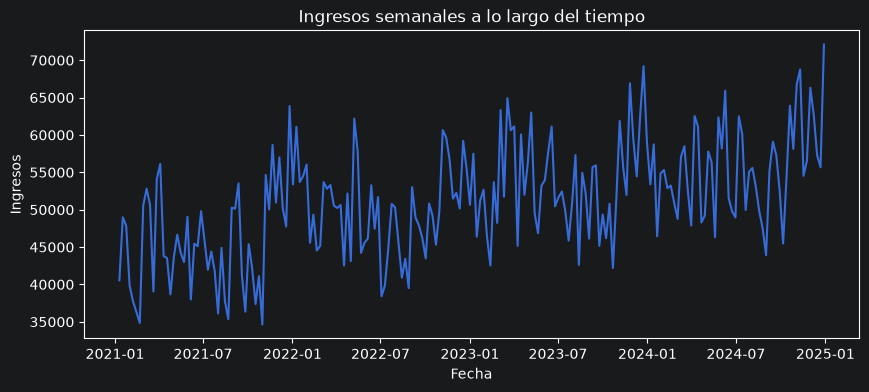

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df["fecha"], df["ingresos"])
ax.set_title("Ingresos semanales a lo largo del tiempo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ingresos")
plt.show()

&emsp;La serie muestra una tendencia de crecimiento a lo largo de los cuatro años,
junto con picos que se repiten cada fin de año. Esta combinación de tendencia y
estacionalidad es justo el tipo de patrón que Prophet está pensado para capturar y es
también la razón por la que se eligió este algoritmo como segundo candidato en el mapa
de selección.

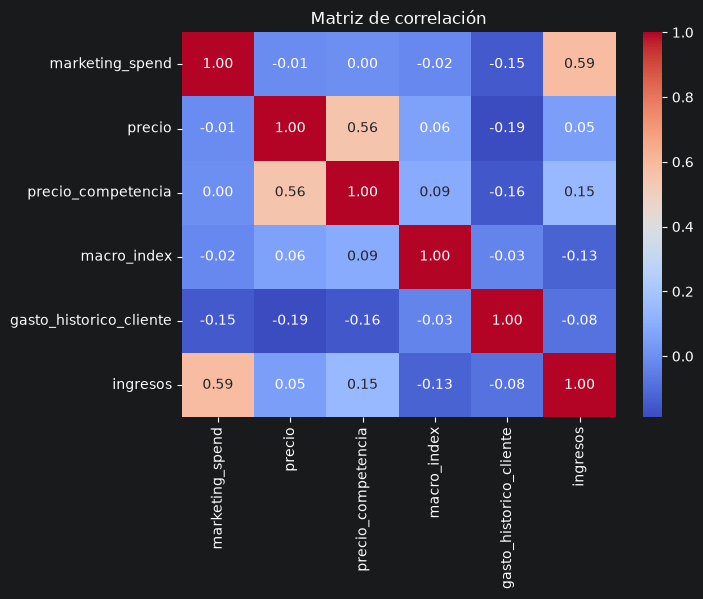

In [6]:
variables_numericas = ["marketing_spend", "precio", "precio_competencia",
                        "macro_index", "gasto_historico_cliente", "ingresos"]

matriz_corr = df[variables_numericas].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Matriz de correlación")
plt.show()

### Multicolinealidad

&emsp;Ninguna pareja de variables predictoras muestra una correlación tan alta entre
sí como para sospechar de multicolinealidad a simple vista. Para confirmarlo con un
número concreto, se calcula el factor de inflación de varianza, VIF, sobre las
variables predictoras.

In [7]:
X_vif = df[["marketing_spend", "precio", "precio_competencia",
            "macro_index", "gasto_historico_cliente"]]
X_vif_const = sm.add_constant(X_vif)

vif = pd.DataFrame()
vif["Variable"] = X_vif_const.columns
vif["VIF"] = [variance_inflation_factor(X_vif_const.values, i)
              for i in range(X_vif_const.shape[1])]

vif

,Variable,VIF
0,const,1.000000
1,marketing_spend,1.025443
2,precio,1.474299
3,precio_competencia,1.463388
4,macro_index,1.009686
5,gasto_historico_cliente,1.067512


&emsp;Los valores de VIF de las variables predictoras se mantienen bajos, lejos del
umbral de 5 o 10 a partir del cual se suele considerar un problema de
multicolinealidad. Esto respalda usar todas estas variables juntas en la regresión
lineal, sin necesidad de eliminar ninguna por redundancia.

### Verificación del supuesto de linealidad

&emsp;El supuesto que se verifica a continuación es la relación lineal entre las
variables predictoras y el ingreso.

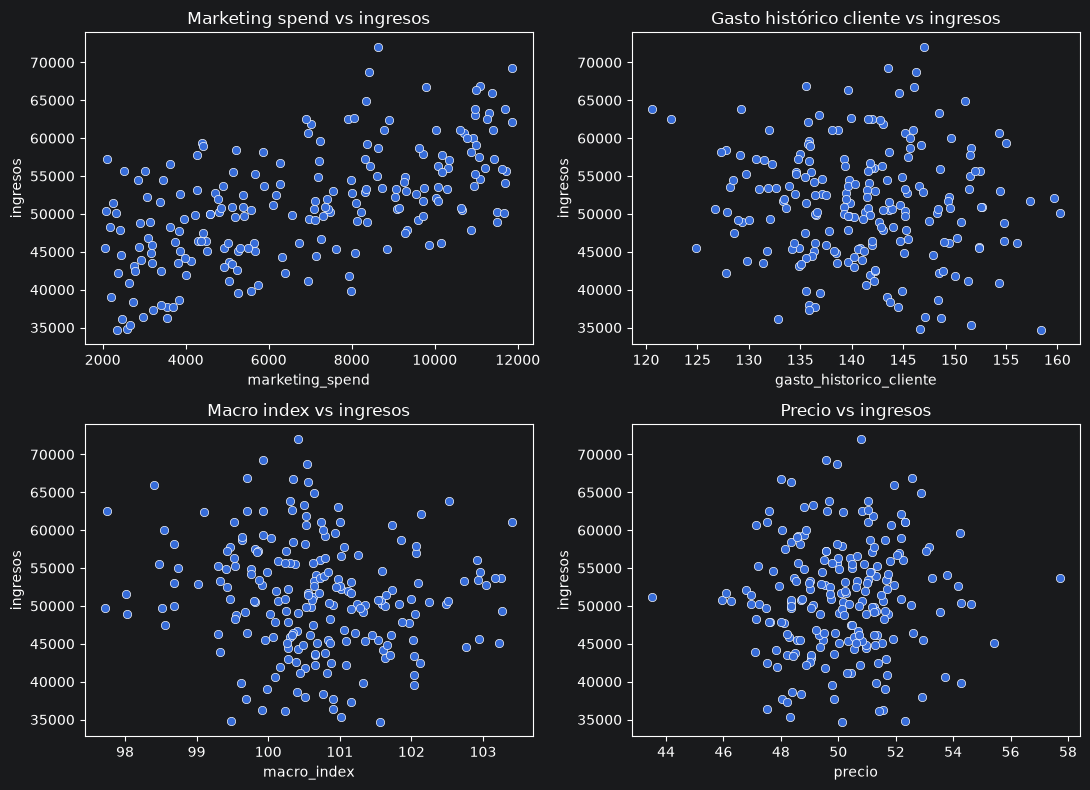

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.scatterplot(data=df, x="marketing_spend", y="ingresos", ax=axes[0, 0])
axes[0, 0].set_title("Marketing spend vs ingresos")

sns.scatterplot(data=df, x="gasto_historico_cliente", y="ingresos", ax=axes[0, 1])
axes[0, 1].set_title("Gasto histórico cliente vs ingresos")

sns.scatterplot(data=df, x="macro_index", y="ingresos", ax=axes[1, 0])
axes[1, 0].set_title("Macro index vs ingresos")

sns.scatterplot(data=df, x="precio", y="ingresos", ax=axes[1, 1])
axes[1, 1].set_title("Precio vs ingresos")

plt.tight_layout()
plt.show()

&emsp;Se ve una tendencia creciente clara entre marketing spend e ingresos y entre
gasto histórico del cliente e ingresos. La relación con el precio es más dispersa,
algo razonable porque el ingreso depende más de la diferencia entre el precio propio y
el de la competencia que del precio por sí solo. En conjunto, estas gráficas confirman
el uso de la regresión lineal como uno de los dos algoritmos candidatos.

## Implementación y comparación de modelos

In [9]:
n_prueba = 20
train = df.iloc[:-n_prueba].copy()
test = df.iloc[-n_prueba:].copy()

print("Semanas de entrenamiento:", len(train))
print("Semanas de prueba:", len(test))

Semanas de entrenamiento: 188
Semanas de prueba: 20


### Modelo 1, regresión lineal múltiple

&emsp;Para capturar la estacionalidad dentro de la regresión lineal, la semana del año
se transforma en dos variables cíclicas, seno y coseno, en lugar de usarla como un
número simple del 1 al 52. Además, se agrega el número de semana consecutiva desde el
inicio del historial como una variable más, para que el modelo tenga forma de captar
el crecimiento de fondo de la empresa a lo largo de los años, algo que no se puede
inferir solo con las variables de negocio.

In [10]:
for base in [train, test]:
    base["semana_sin"] = np.sin(2 * np.pi * base["semana_del_anio"] / 52)
    base["semana_cos"] = np.cos(2 * np.pi * base["semana_del_anio"] / 52)

columnas_predictoras = [
    "marketing_spend", "precio", "precio_competencia", "macro_index",
    "gasto_historico_cliente", "semana_sin", "semana_cos", "semana_index",
]

X_train = train[columnas_predictoras]
y_train = train["ingresos"]
X_test = test[columnas_predictoras]
y_test = test["ingresos"]

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

pred_lineal_train = modelo_lineal.predict(X_train)
pred_lineal_test = modelo_lineal.predict(X_test)

mae_lineal = mean_absolute_error(y_test, pred_lineal_test)
rmse_lineal = mean_squared_error(y_test, pred_lineal_test) ** 0.5
r2_lineal = r2_score(y_test, pred_lineal_test)

print("Regresión lineal, métricas de prueba")
print("MAE:", round(mae_lineal, 2))
print("RMSE:", round(rmse_lineal, 2))
print("R2:", round(r2_lineal, 4))

Regresión lineal, métricas de prueba
MAE: 4032.19
RMSE: 4638.45
R2: 0.615


### Modelo 2, Prophet

&emsp;Prophet espera dos columnas fijas, una fecha llamada ds y un valor llamado y.
Las demás variables se agregan como regresores adicionales.

In [11]:
train_prophet = train.rename(columns={"fecha": "ds", "ingresos": "y"})
test_prophet = test.rename(columns={"fecha": "ds", "ingresos": "y"})

regresores = ["marketing_spend", "precio", "precio_competencia",
              "macro_index", "gasto_historico_cliente"]

modelo_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False)
for reg in regresores:
    modelo_prophet.add_regressor(reg)

modelo_prophet.fit(train_prophet[["ds", "y"] + regresores])

16:28:56 - cmdstanpy - INFO - Chain [1] start processing
16:28:56 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
futuro_train = train_prophet[["ds"] + regresores]
futuro_test = test_prophet[["ds"] + regresores]

pred_prophet_train = modelo_prophet.predict(futuro_train)["yhat"].values
pred_prophet_test = modelo_prophet.predict(futuro_test)["yhat"].values

mae_prophet = mean_absolute_error(y_test, pred_prophet_test)
rmse_prophet = mean_squared_error(y_test, pred_prophet_test) ** 0.5
r2_prophet = r2_score(y_test, pred_prophet_test)

print("Prophet, métricas de prueba")
print("MAE:", round(mae_prophet, 2))
print("RMSE:", round(rmse_prophet, 2))
print("R2:", round(r2_prophet, 4))

Prophet, métricas de prueba
MAE: 2630.93
RMSE: 3077.54
R2: 0.8305


In [13]:
comparacion = pd.DataFrame({
    "Modelo": ["Regresion lineal", "Prophet"],
    "MAE": [mae_lineal, mae_prophet],
    "RMSE": [rmse_lineal, rmse_prophet],
    "R2": [r2_lineal, r2_prophet],
})
comparacion

,Modelo,MAE,RMSE,R2
0,Regresion lineal,4032.193477,4638.445636,0.615039
1,Prophet,2630.927145,3077.539798,0.830535


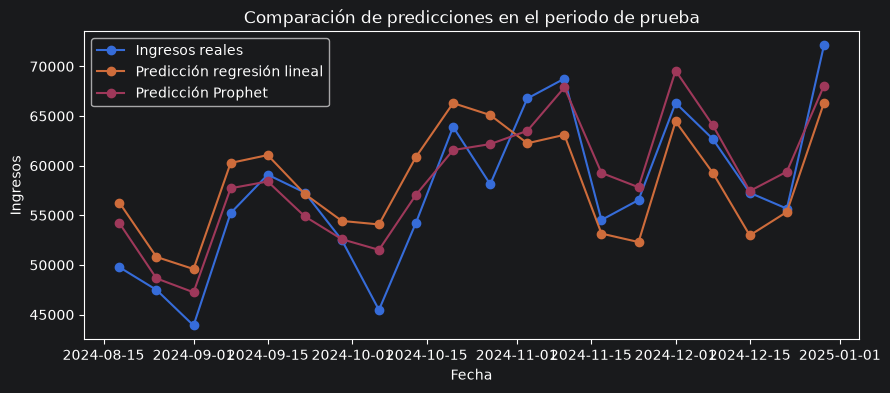

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test["fecha"], y_test, label="Ingresos reales", marker="o")
ax.plot(test["fecha"], pred_lineal_test, label="Predicción regresión lineal", marker="o")
ax.plot(test["fecha"], pred_prophet_test, label="Predicción Prophet", marker="o")
ax.set_title("Comparación de predicciones en el periodo de prueba")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ingresos")
ax.legend()
plt.show()

## Análisis de límites y riesgos

### Sobreajuste

&emsp;Para revisar si algún modelo memorizó el periodo de entrenamiento en lugar de
aprender un patrón general.

In [15]:
r2_lineal_train = r2_score(y_train, pred_lineal_train)
r2_prophet_train = r2_score(y_train, pred_prophet_train)

overfitting_check = pd.DataFrame({
    "Modelo": ["Regresion lineal", "Prophet"],
    "R2 entrenamiento": [r2_lineal_train, r2_prophet_train],
    "R2 prueba": [r2_lineal, r2_prophet],
})
overfitting_check["Diferencia"] = (
    overfitting_check["R2 entrenamiento"] - overfitting_check["R2 prueba"]
)
overfitting_check

,Modelo,R2 entrenamiento,R2 prueba,Diferencia
0,Regresion lineal,0.738120,0.615039,0.123081
1,Prophet,0.866461,0.830535,0.035925


&emsp;Una diferencia grande entre el R2 de entrenamiento y el de prueba es señal de
que el modelo no generaliza bien fuera del periodo con el que aprendió. Como se puede ver, la diferencia para el de Prophet es pequeña y menor que en la regresión lineal.

### Efecto de un valor atípico

&emsp;Se agrega al set de entrenamiento una semana con un ingreso fuera de lo normal,
como podría pasar por un evento puntual que no está representado en las variables del
modelo y se revisa el efecto sobre la regresión lineal. Lo famosos *outliers*

In [16]:
X_train_outlier = X_train.copy()
y_train_outlier = y_train.copy()

outlier_row = X_train.iloc[[0]].copy()
X_train_outlier = pd.concat([X_train_outlier, outlier_row], ignore_index=True)
y_train_outlier = pd.concat(
    [y_train_outlier, pd.Series([y_train.max() * 3])], ignore_index=True
)

modelo_lineal_outlier = LinearRegression()
modelo_lineal_outlier.fit(X_train_outlier, y_train_outlier)
pred_lineal_outlier = modelo_lineal_outlier.predict(X_test)
r2_lineal_outlier = r2_score(y_test, pred_lineal_outlier)

print("R2 de regresion lineal sin el valor atipico:", round(r2_lineal, 4))
print("R2 de regresion lineal con el valor atipico:", round(r2_lineal_outlier, 4))

R2 de regresion lineal sin el valor atipico: 0.615
R2 de regresion lineal con el valor atipico: 0.5867


&emsp;El resultado muestra que el R2 de la regresión lineal cae al entrenar con un
solo valor fuera de rango. Esto pasa porque el modelo calcula sus coeficientes
buscando el mejor ajuste sobre todos los puntos a la vez, incluido el atípico, y ese
único punto puede mover la línea de forma notoria. Un modelo como Prophet, al
construirse a partir de una tendencia y una estacionalidad que se estiman con toda la
serie, suele diluir mejor el efecto de un solo punto fuera de lo normal, aunque
tampoco queda libre del todo si el valor atípico se repite en varias semanas seguidas.

### Datos no representativos

&emsp;Otro riesgo a considerar es que los datos usados para entrenar no representen
todo el rango en el que después se va a usar el modelo. Si en la historia real nunca
se ha invertido más de doce mil dólares semanales en marketing, ninguno de los dos
modelos debería usarse para estimar el efecto de una inversión de treinta mil, porque
estarían prediciendo fuera del rango que aprendieron.

### Interpretabilidad

&emsp;Por último, la interpretabilidad también es un límite a tomar en cuenta. La
regresión lineal permite mostrar un coeficiente por cada variable, algo directo de
explicar a finanzas o a dirección. Prophet se explica más a través de sus gráficos de
tendencia y estacionalidad, lo cual sigue siendo entendible para el negocio, pero no
da un número único tan directo como un coeficiente para responder cuánto sube el
ingreso por cada dólar adicional de marketing.

## Consideraciones éticas

### Equidad

&emsp;El modelo no usa datos personales de clientes individuales, sino variables
agregadas a nivel de toda la empresa, como el gasto histórico promedio.Por lo tanto, no se espera causar algún sesgo o discriminar.  Aun así, si en
el futuro se agregan variables por región o por tienda, conviene revisar que el error
de predicción sea parecido entre esos grupos, porque un modelo que funciona bien solo
para una parte del negocio y mal para otra puede llevar a decisiones de presupuesto
injustas entre regiones.

### Transparencia

&emsp;Para que el modelo sea transparente frente al equipo financiero, conviene
documentar junto con la predicción qué variables se usaron, el periodo de datos con el
que se entrenó, y cómo se comporta el error del modelo en distintas temporadas del
año. Cuando se necesite justificar una decisión específica de presupuesto ante
dirección, conviene apoyarse en la regresión lineal, porque sus coeficientes explican
de forma directa el efecto esperado de cada variable.

### Privacidad

&emsp;En cuanto a privacidad, este ejercicio no usa información de clientes
individuales, solo cifras agregadas de la empresa. Si en un caso real se llegara a
usar información más detallada del comportamiento de clientes, convendría trabajar
con datos agregados por segmento en lugar de datos identificables de cada persona y
confirmar que cualquier dato sobre precios de la competencia provenga de fuentes
públicas.

## Conclusión y recomendación final

&emsp;El modelo recomendado es Prophet. En el periodo de prueba obtuvo un error menor
que la regresión lineal, tanto en MAE como en RMSE y un R2 más alto. Además, al
comparar su desempeño entre entrenamiento y prueba, la diferencia fue pequeña, lo que
indica que aprendió un patrón que se sostiene fuera del periodo con el que se entrenó.
La regresión lineal, aunque también tuvo un desempeño razonable una vez que se le
agregó una variable de tendencia, mostró una diferencia mayor entre su R2 de
entrenamiento y de prueba, además de una caída notoria en su R2 al introducir un solo
valor atípico durante la prueba de sensibilidad.

&emsp;Esto confirma lo esperado desde el mapa de selección de algoritmos, un modelo
pensado para series de tiempo, con tendencia y estacionalidad incorporadas de forma
directa, tiene ventaja sobre una regresión lineal cuando el propio patrón de ventas
depende tanto del calendario como del negocio. La regresión lineal se mantiene como un
modelo de apoyo útil para explicar de forma directa el efecto esperado de una variable
específica, por ejemplo cuánto sube el ingreso por cada dólar adicional de marketing,
algo que Prophet no ofrece con la misma facilidad.

&emsp;En términos de aplicación práctica, el área de planeación puede usar Prophet
para ajustar el inventario con varias semanas de anticipación y apoyarse en la
regresión lineal cuando necesite justificar ante dirección el efecto puntual de una
variable de negocio. Esta combinación responde al objetivo estratégico de anticipar el
flujo de caja de la empresa sin perder la posibilidad de explicar de forma clara las
decisiones que se toman a partir del modelo.